# DC magnetometry and robust-pulse optimization with an NV center

One of the best-known applications of the NV center is as a **magnetometer**: its electron-spin
resonance shifts with an applied magnetic field (Zeeman effect), so measuring that shift reveals
the field. This notebook has three parts.

**Part 1** measures a static (DC) field with a **Ramsey sequence**, reads it out by **slope
detection**, and defines the figure of merit a magnetometer is judged by, the **sensitivity**
$\eta$.

**Part 2** moves from one spin to an **ensemble**, as real diamond magnetometers do to sense with many
spins at once. Packing NV centres into the crystal spreads their resonances (**inhomogeneous
broadening**), so a rectangular $\pi/2$ mis-rotates the off-resonant spins and the fringe dephases
during the free evolution; both erode the fringe **contrast**, and &mdash; since $\eta \propto 1/C$
&mdash; the sensitivity with it. We watch the Ramsey fringe wash out and then quantify the loss as the
linewidth grows.

**Part 3** then repairs it with **optimal control**: we use <span style="font-variant: small-caps;">Simphony</span>'s
**automatic differentiation** to shape the control pulses so the sensitivity survives the ensemble,
optimizing the sensing figure of merit itself. This mirrors Jauch *et al.*, ["Enhancing the Ramsey
contrast of an NV-ensemble in diamond using quantum optimal control"](https://doi.org/10.1088/2058-9565/adffb2),
Quantum Sci. Technol. **10**, 045028 (2025), who experimentally recover the Ramsey contrast of an
inhomogeneous NV ensemble with optimal-control pulses.

We assume familiarity with the components, pulses, and Ramsey workflow from the basic tutorial and
from `6_example_ramsey_with_quasistatic_noise.ipynb`; autodiff pulse optimization is introduced in
`3_tutorial_autodiff_gate_optimization.ipynb`.

## Import the packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import simphony

simphony.Config.set_platform('cpu')
simphony.Config.set_matplotlib_format('retina')

## Part 1: Sensing a DC field with a single spin

How small a magnetic field can a single NV spin resolve, and what sets that limit? The measurement
turns a field into an **estimate** in a few steps: the field shifts the spin's resonance (Zeeman
effect, gain $\gamma_e$), a **Ramsey sequence** lets that shift accumulate as a **phase** on a
superposition, the phase is turned into a **population** we read out, and inverting that readout
(linear inversion at the working point) gives the field back.

$$B \;\xrightarrow{\;\gamma_e\;}\; \text{detuning } \delta = \gamma_e B
   \;\xrightarrow{\;\text{free evolution }\tau\;}\; \text{phase }\phi
   \;\xrightarrow{\;\text{readout}\;}\; \text{population }p
   \;\longrightarrow\; B_\text{est}$$

The quality of the whole measurement is a single number &mdash; the **sensitivity** $\eta$ &mdash;
and it is set by just three factors: the transducer gain $\gamma_e$ (fixed by nature), the sensing
time $\tau$, and the fringe **contrast** $C$ &mdash; the depth (or visibility) of the interference
fringe, from 1 (full swing) down to 0 (washed out). In a real NV experiment the contrast a device
actually reaches also folds in the **optical spin-readout contrast** (the fractional fluorescence
difference between $m_s{=}0$ and $m_s{=}\pm1$, typically only a few tens of percent); the two
multiply, and we track the interferometric part here, taking an ideal readout. We meet each of the three factors while building the measurement below, then assemble them
into $\eta$ at the end.

### Model and $\pi/2$ pulse calibration

We use the bare NV electron (no nuclear spin) so the Ramsey signal is a single clean fringe. We set a
static bias field of $0.05\,\mathrm{T}$ along $z$ and calibrate a resonant $\pi/2$ pulse against it.
The free-evolution time `wait` sets the sensing time $\tau$ &mdash; the second of the three factors. We
calibrate the $\pi/2$ pulse once here; that pulse and `wait` are then reused in every sequence below.

In [2]:
model = simphony.default_nv_model(static_field_strength=0.05)
frequency = model.splitting_qubit('e')  # transition frequency [MHz]
gyromagnetic_ratio = model.spin('e').gyromagnetic_ratio  # [MHz/T]

wait = 0.05  # free-evolution (sensing) time [us]
duration = 0.03  # rectangular pi/2 duration [us]
angle = np.pi / 2
period_time = 2 * np.pi * duration / angle
amplitude = model.rabi_amplitude_qubit(driving_field_name='MW_x',
                                       period_time=period_time,
                                       spin_name='e')  # [T]
rabi_frequency = 1.0 / period_time  # [MHz] full 2*pi Rabi cycle -> Omega

print(f'transition frequency = {frequency:.2f} MHz')
print(f'gyromagnetic_ratio   = {gyromagnetic_ratio:.1f} MHz/T')
print(f'Rabi frequency Omega = {rabi_frequency:.2f} MHz   (pi/2 in {duration*1e3:.0f} ns = a quarter cycle)')
print(f'pi/2 amplitude       = {amplitude * 1e3:.4f} mT')

def append_rectangular_ramsey(scale, readout_phase):
    '''A Ramsey sequence (pi/2 - wait - pi/2) on MW_x scale rescales the amplitude (1.0 = calibrated).'''
    model.driving_field('MW_x').add_rectangle_pulse(amplitude=amplitude * scale,
                                                    frequency=frequency,
                                                    phase=0.,
                                                    duration=duration)
    model.driving_field('MW_x').add_wait(wait)
    model.driving_field('MW_x').add_rectangle_pulse(amplitude=amplitude * scale,
                                                    frequency=frequency,
                                                    phase=readout_phase,
                                                    duration=duration)

transition frequency = 1470.35 MHz
gyromagnetic_ratio   = 28033.1 MHz/T
Rabi frequency Omega = 8.33 MHz   (pi/2 in 30 ns = a quarter cycle)
pi/2 amplitude       = 0.4204 mT


### Stage 1: field &rarr; phase &rarr; population

To sense a field $B$ along $z$ we model it as a **driving field with constant amplitude and zero
frequency** &mdash; a steady field switched on for the sequence. During the free evolution for a time
$\tau$ this field winds up a **phase** $\phi = 2\pi\,\gamma_e B\,\tau$ on the superposition, so the
gain $\gamma_e$ and the time $\tau$ fix how much phase a given field buys.
The second $\pi/2$ turns that phase into a **population**, and that population is what we read out
&mdash; it is the expectation value of the $m_s = 0$ projector, the spin-dependent **fluorescence**
signal a real NV magnetometer detects, $M = |0\rangle\langle 0|$. So $\langle M\rangle \in [0,1]$
*is* the measured quantity, with no post-processing.

Reading along the preparation axis (`readout_phase = 0`) and sweeping $B$ traces a **Ramsey fringe**
in $\langle M\rangle$ &mdash; the field turned into a signal.

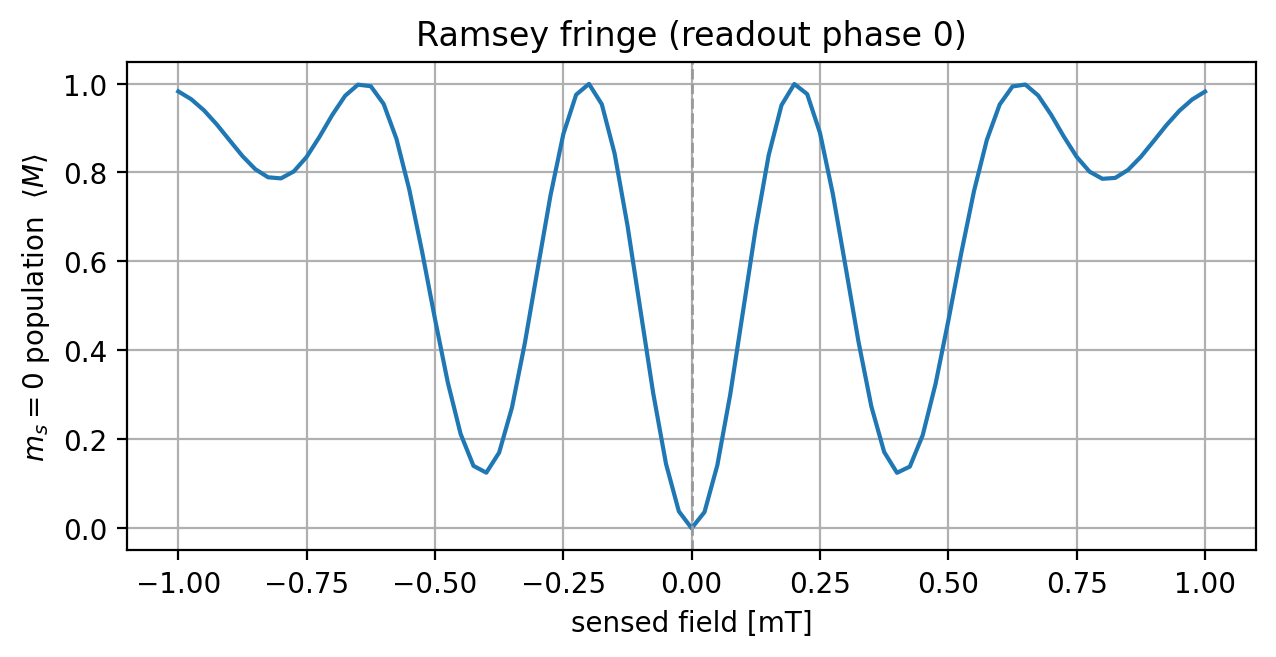

In [3]:
driving_field = simphony.LinearDrivingField(name='DC_z', direction=[0, 0, 1])
model.add_driving_field(driving_field)

def ramsey_signal(field, readout_phase=0.0):
    '''Measured m_s=0 population <M> for a sensed field [T] readout_phase rotates the second pi/2 axis.'''
    model.remove_all_pulses()
    append_rectangular_ramsey(1.0, readout_phase)
    end = model.driving_field('MW_x').last_pulse_end
    model.driving_field('DC_z').add_rectangle_pulse(amplitude=field,
                                                    frequency=0.,
                                                    phase=0.,
                                                    duration=end,
                                                    start=0.)
    result = model.simulate_time_evolution(n_eval=2,
                                           n_split=50)
    result.initial_state = model.productstate({'e': 0})
    population = result.expectation_value('M', t_idx=-1)
    return population[0, 0].item()

fields = np.linspace(-1e-3, 1e-3, 81)  # +-1 mT
fringe_single = np.array([ramsey_signal(field, readout_phase=0.0) for field in fields])

plt.figure(figsize=(6.5, 3.4))
plt.plot(fields * 1e3, fringe_single, '-')
plt.axvline(0.0, color='0.6', lw=1, ls='--')
plt.xlabel('sensed field [mT]')
plt.ylabel(r'$m_s{=}0$ population  $\langle M\rangle$')
plt.title('Ramsey fringe (readout phase 0)')
plt.grid()
plt.tight_layout()
plt.show()

The fringe bears out the physics: $B=0$ lands on an **extremum**, where the response is flat. The
oscillation also **shrinks toward the edges of the sweep** &mdash; the field is on during the $\pi/2$
pulses too, so at $B=\pm1$&nbsp;mT the Zeeman shift ($\gamma_e B\approx28$&nbsp;MHz) rivals the pulses'
own Rabi frequency ($\approx8.3$&nbsp;MHz), detuning them so they mis-rotate the spin. Neither affects
what follows: slope detection operates at $B=0$, and the recovered field is microtesla-scale, far
below where this sets in.

### Stage 2: reading it out &mdash; slope detection

The readout gives the $m_s=0$ population $p \equiv \langle M\rangle$, a probability in $[0,1]$. To
invert $p \to B$ we need the **response** $dp/dB$, and where we sit
on the fringe sets it. On the fringe above, $B=0$ sits on an **extremum**, where the response is flat
($\delta p \approx 0$ to first order in $B$) &mdash; a blind spot. The fix is to **rotate the readout
axis**: taking `readout_phase = pi/2` shifts the working point a quarter period, onto the **steep
midpoint** $p_0 = 0.5$, where the response is largest and linear. Running the sensor there is
**slope detection** (Degen *et al.*, ["Quantum Sensing"](https://arxiv.org/abs/1611.02427), Secs. III.C,
V.E). The scan below confirms $|dp/dB|$ is largest at
$\pi/2$ and vanishes at the extrema, then reads off the working-point slope.

<details>
<summary>The working-point slope and effective sensing time</summary>

At the working point (readout phase $\pi/2$) the population traces a sine of the sensed field,

$$p(B) = \tfrac12\bigl(1 + C\,\sin(2\pi\gamma_e B\,\tau_\text{eff})\bigr),$$

symmetric about $p_0 = \tfrac12$ and steepest at $B = 0$. Differentiating there gives the
working-point slope

$$\left|\frac{dp}{dB}\right|_\text{max} = \pi\,\gamma_e\,\tau_\text{eff}\,C,$$

which packs all three ingredients of the response into one number: the gyromagnetic gain $\gamma_e$,
the fringe contrast $C$, and $\tau_\text{eff}$, the **effective sensing time** &mdash; the interval
over which the field actually winds up phase. It comes out a little longer than `wait`, because the
field keeps tilting the spin during the two finite $\pi/2$ pulses as well, not only during the free
evolution between them. Rather than assume it, we read it straight off the measured slope:

$$\tau_\text{eff} = \frac{|dp/dB|_\text{max}}{\pi\,\gamma_e\,C}\qquad(C \approx 1\ \text{for the single spin}).$$

The printed value, $\tau_\text{eff} \approx 88$ ns, duly sits between `wait` $= 50$ ns and the full
sequence length $110$ ns.

</details>

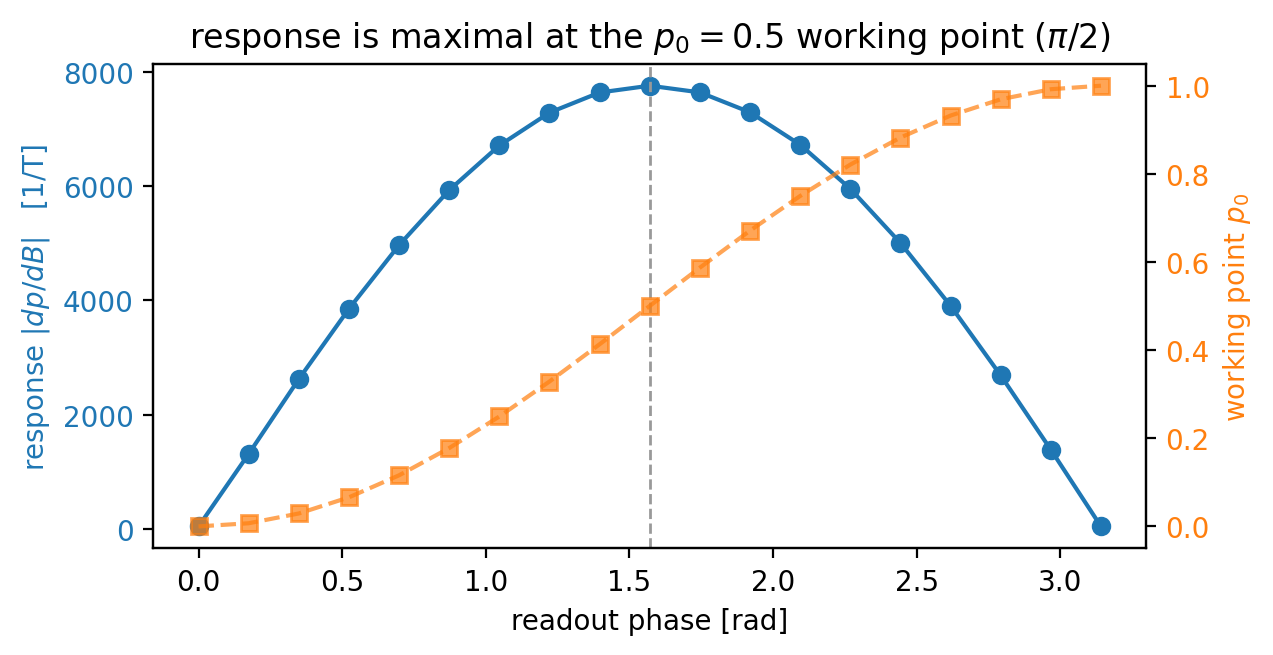

working point p0       = 0.5003   (expect 0.5)
response |dp/dB|       = 7765 1/T
effective sensing time = 88.2 ns   (between wait = 50 ns and the full sequence = 110 ns: the field acts during the two pi/2 pulses too)


In [4]:
def slope_at(readout_phase, delta=1e-9):
    '''Response dp/dB at B=0 for a given readout phase (central finite difference of <M>).'''
    return (ramsey_signal(delta, readout_phase) - ramsey_signal(-delta, readout_phase)) / (2 * delta)

# Illustration: the response |dp/dB| and the working point p0 across readout phases. The response is
# largest exactly where p0 = 0.5 (readout phase pi/2) and vanishes at the fringe extrema.
readout_scan = np.linspace(0, np.pi, 19)
slope_scan = np.array([slope_at(phase) for phase in readout_scan])
p0_scan = np.array([ramsey_signal(0.0, phase) for phase in readout_scan])

fig, ax1 = plt.subplots(figsize=(6.5, 3.4))
ax1.plot(readout_scan, np.abs(slope_scan), 'o-', color='C0')
ax1.axvline(np.pi / 2, color='0.6', lw=1, ls='--')
ax1.set_xlabel('readout phase [rad]')
ax1.set_ylabel(r'response $|dp/dB|$   [1/T]', color='C0')
ax1.tick_params(axis='y', labelcolor='C0')
ax2 = ax1.twinx()
ax2.plot(readout_scan, p0_scan, 's--', color='C1', alpha=0.7)
ax2.set_ylabel(r'working point $p_0$', color='C1')
ax2.tick_params(axis='y', labelcolor='C1')
ax1.set_title(r'response is maximal at the $p_0=0.5$ working point ($\pi/2$)')
plt.tight_layout()
plt.show()

# Operate at the working point, readout phase pi/2.
p0 = ramsey_signal(0.0, np.pi / 2)
slope = slope_at(np.pi / 2)
tau_eff = abs(slope) / (np.pi * gyromagnetic_ratio)  # effective sensing time from |dp/dB| = pi*gamma*tau_eff*C
print(f'working point p0       = {p0:.4f}   (expect 0.5)')
print(f'response |dp/dB|       = {abs(slope):.0f} 1/T')
sequence_length = 2 * duration + wait  # full pi/2 - wait - pi/2 duration [us]
print(f'effective sensing time = {tau_eff * 1e3:.1f} ns   (between wait = {wait * 1e3:.0f} ns and the full sequence = {sequence_length * 1e3:.0f} ns: the field acts during the two pi/2 pulses too)')

### The limit: how small a field can we resolve?

Two things set the smallest resolvable field: how strongly the field moves the readout (the slope we
just measured) and how noisy each readout is. At the working point the response is linear,
$|dp/dB| = \pi\gamma_e\tau C$, and projection noise on $p$, averaged over the measurement time, gives
the shot-noise-limited **sensitivity**

$$\boxed{\;\eta_B \;=\; \frac{1}{\gamma_e\, C\, \sqrt{\tau}}\;}$$

with three factors, each from one step of the measurement: the transducer gain $\gamma_e$
(field&rarr;phase), the sensing time $\tau$ (phase accumulated), and the **contrast** $C \in [0,1]$.
Here $C$ is an *effective* contrast that folds in two things which multiply: the **Ramsey fringe
visibility** (how deep the interference fringe is, set by the pulses and dephasing) and the
**fluorescence readout contrast** (how well the weak optical readout tells $m_s{=}0$ from
$m_s{=}\pm1$ &mdash; only a few percent for a room-temperature NV, where the readout is
photon-shot-noise-limited). Since $\eta_B \propto 1/C$, the contrast is the factor you can fight for.

<details>
<summary>Where the formula comes from</summary>

Each shot ends in a **projective** readout, so the estimated population $p$ carries irreducible quantum
noise. At the working point $p_0 = \tfrac12$ a single shot has the largest possible spread,
$\delta p = \sqrt{p_0(1-p_0)} = \tfrac12$, and averaging $n_\text{shot}$ independent repetitions
narrows it as

$$\delta p = \frac{1}{2\sqrt{n_\text{shot}}}.$$

What the Ramsey sequence really estimates, though, is not $p$ itself but the accumulated **phase**
$\phi = 2\pi\gamma_e B\,\tau$. Near the working point the fringe slope is $|dp/d\phi| = C/2$, so the
population noise becomes a phase uncertainty

$$\delta\phi = \frac{\delta p}{|dp/d\phi|} = \frac{1}{C\sqrt{n_\text{shot}}}$$

&mdash; the standard interferometer limit: a full-contrast fringe ($C = 1$) resolves about one radian
per shot, and averaging buys $\sqrt{n_\text{shot}}$. Inverting $\phi = 2\pi\gamma_e B\,\tau$ carries
this back into a field uncertainty, $\delta B = \delta\phi / (2\pi\gamma_e\,\tau)$. Finally, a fixed
total time $T$ buys $n_\text{shot} = T/\tau$ shots, so $\delta B$ falls as $1/\sqrt{T}$; writing that
as $\delta B = \eta_B/\sqrt{T}$ and dropping the order-1 $2\pi$ leaves the sensitivity

$$\eta_B = \frac{1}{\gamma_e\,C\,\sqrt{\tau}}.$$

(The $C$ in this derivation is the interferometric fringe visibility; the fluorescence readout
contrast folds in on top, as noted above &mdash; see Taylor 2008; Barry 2020.)

</details>

**What caps the sensing time.** The response grows with $\tau$, so you would take $\tau \to \infty$ and
resolve any field &mdash; except the fringe **decoheres**: past the coherence time $T_2^*$ the contrast
collapses, so the useful sensing time is capped at $\tau \lesssim T_2^*$. Here the spin is ideal and
$C = 1$, so the fringe swings the full $0 \to 1$:

In [5]:
def sensitivity(contrast):
    '''Shot-noise-limited sensitivity [T/sqrt(Hz)] gyromagnetic_ratio -> Hz/T, wait -> s.'''
    return 1.0 / (gyromagnetic_ratio * 1e6 * max(contrast, 1e-9) * np.sqrt(wait * 1e-6))

print(f'contrast C            = 1.0   (single ideal spin, full swing)')
print(f'ideal sensitivity eta = {sensitivity(1.0):.3e} T/sqrt(Hz) = {sensitivity(1.0) * 1e9:.1f} nT/sqrt(Hz)')

contrast C            = 1.0   (single ideal spin, full swing)
ideal sensitivity eta = 1.595e-07 T/sqrt(Hz) = 159.5 nT/sqrt(Hz)


### Putting it to work: recovering an unknown field

The measurement now runs end to end. We treat the field as unknown: the analysis below uses only the
measured signal, as a real measurement does, and compares against the true value at the end. With the
instrument calibrated ($p_0$ and the slope), a **single** measurement at the working point recovers
the field by linear inversion, $B_\text{est} = (p - p_0)/(dp/dB)$.

In [6]:
unknown_field = 8e-6  # T -- used only via the measured signal

p_measured = ramsey_signal(unknown_field, np.pi / 2)
estimated_field = (p_measured - p0) / slope

print(f'measured p         = {p_measured:.5f}')
print(f'estimated field    = {estimated_field * 1e6:.4f} uT')
print(f'true field         = {unknown_field * 1e6:.4f} uT')
print(f'relative error     = {abs(estimated_field - unknown_field) / abs(unknown_field):.2e}')

measured p         = 0.56223
estimated field    = 7.9789 uT
true field         = 8.0000 uT
relative error     = 2.64e-03


The recovery is essentially exact because this notebook is **noiseless**. In practice the three
factors behave very differently. $\gamma_e$ is **fixed by nature**. The sensing time $\tau$ is
**capped by dephasing** &mdash; grow it past the coherence time and the fringe washes out. That
coherence time is set by how spread-out the ensemble's resonance frequencies are &mdash; the quantity
Part 2 introduces and quantifies (shot noise and $T_2^*$ are modeled in
`6_example_ramsey_with_quasistatic_noise.ipynb`). That leaves
the **contrast $C$** as the factor you can actually fight for &mdash; and in a real device it is the
one under threat: an **ensemble** of spins with spread-out resonances loses contrast fast. **Part 2**
shows how the contrast collapses; **Part 3** recovers it with an optimized pulse.

## Part 2: The ensemble and the contrast

A single NV resolves maybe $\sim\mu\text{T}/\sqrt{\text{Hz}}$; a real diamond magnetometer instead
reads out **many NVs at once** &mdash; a macroscopic crystal holds $10^9$&ndash;$10^{12}$ of them, and
$N$ spins together give a $\sqrt{N}$ sensitivity boost (down to $\text{fT}$&ndash;$\text{pT}/\sqrt{\text{Hz}}$).
It is tempting to get that $N$ by simply **packing the NVs denser**, but density is self-defeating:
denser spins broaden one another's resonance, and that broadening is precisely what collapses the
fringe **contrast** $C$ (below). So the $\sqrt{N}$ gain comes from a larger sensing **volume**, not a
higher density &mdash; and there is an **optimal density** beyond which more NVs stop helping. Here we
hold the per-spin picture and isolate that contrast collapse.

<details>
<summary>Why there's an optimal NV density</summary>

Raising the density pulls two ways at once:

- **more spins** &mdash; $N$ is the density times the sensing volume, and the signal-to-noise grows
  as $\sqrt{N}$;
- **worse coherence** &mdash; a denser NV (and nitrogen) bath widens the spread of resonance
  frequencies, $\sigma \propto$ density. This is the same $\sigma$ that shrinks the contrast $C$ and
  the coherence time $T_2^* \approx 1/(2\pi\sigma)$ studied here.

At a fixed volume the two roughly **cancel**: packing tighter gives more spins but each one is worse,
so past an **optimal density** the added broadening eats the added spins and more NVs stop helping.
The sensitivity therefore improves with the number of *useful* spins &mdash; which you grow with a
larger crystal (more **volume**), not by squeezing harder. (A single NV is one spin in a vanishing
volume, so it has no $\sqrt{N}$ at all &mdash; that is why an ensemble beats it.)

This is where **Part 3** comes in: recovering the contrast lost to broadening lets the ensemble
tolerate a larger $\sigma$ (a denser packing) before the signal collapses, so the optimal density
**shifts upward** &mdash; more useful NVs in the same volume, and a better sensitivity.

</details>

#### Modelling the broadening

We model the broadening as a normally distributed *static* detuning of width $\sigma$ (in MHz). This
$\sigma$ is not a new parameter: it **is** the linewidth that set the $T_2^*$ limit of Part 1, through
$T_2^* \approx 1/(2\pi\sigma)$. So $\sigma = 4$ MHz means $T_2^* \approx 40$ ns &mdash; comparable to
the Ramsey `wait`, which is why the sensing time here is short. To sample the distribution, instead of using e.g. Monte Carlo, we take the weighted average of 11 different linewidth perturbation.

Two things then erode the contrast $C$ as $\sigma$ grows: (i) a rectangular $\pi/2$ only rotates a
resonant spin correctly &mdash; off-resonant spins mis-rotate; and (ii) during the free evolution the
spread of static detunings winds the fringes out of step (the $T_2^*$ dephasing). We scan $\sigma$ up
to $\sim4$ MHz (about half the Rabi frequency $\Omega \approx 8.3$ MHz), measuring $C$ as the amplitude
of the first harmonic of $\langle M\rangle$ over three readout phases (illustrated just below), averaged
over the Gaussian detuning distribution deterministically.

In [7]:
readout_phases = np.array([0.0, 2 * np.pi / 3, 4 * np.pi / 3])

def contrast_first_harmonic(signals, readout_phases):
    '''Fringe visibility C in [0,1] from the m_s=0 population <M> sampled at the given readout phases.
    The factor of 2 is because <M> = 1/2 (1 + C cos) swings by only C peak-to-peak, half the
    first-harmonic phasor amplitude.'''
    signals = np.asarray(signals)
    cos_component = (2 / len(signals)) * np.sum(signals * np.cos(readout_phases))
    sin_component = (2 / len(signals)) * np.sum(signals * np.sin(readout_phases))
    return float(2 * np.hypot(cos_component, sin_component))

# Average over the Gaussian inhomogeneous-detuning distribution deterministically, using Gauss-Hermite quadrature
gauss_nodes, gauss_weights = np.polynomial.hermite_e.hermegauss(11)
gauss_weights = gauss_weights / np.sqrt(2 * np.pi)  # standard-normal weights, sum to 1

def ensemble_population(append_ramsey, sigma, readout_phase, field=0.0):
    '''Ensemble-averaged m_s=0 population <M> for a detuning std sigma [MHz] and a sensed field [T].'''
    population = 0.0
    for node, weight in zip(gauss_nodes, gauss_weights):
        model.remove_all_pulses()
        append_ramsey(1.0, readout_phase)  # pi/2 - wait - pi/2 on MW_x
        end = model.driving_field('MW_x').last_pulse_end
        model.driving_field('DC_z').add_rectangle_pulse(amplitude=field + (sigma * node) / gyromagnetic_ratio,
                                                        frequency=0.,
                                                        phase=0.,
                                                        duration=end,
                                                        start=0.)
        result = model.simulate_time_evolution(n_eval=2,
                                               n_split=50,
                                               apply_noise=False)
        result.initial_state = model.productstate({'e': 0})
        population += weight * result.expectation_value('M',
                                                        t_idx=-1,
                                                        in_qubit_subspace=False)[0, 0].item()
    return population

def ramsey_contrast(append_ramsey, sigma):
    signals = [ensemble_population(append_ramsey, sigma, phase) for phase in readout_phases]
    return contrast_first_harmonic(signals, readout_phases)

**Why three readout phases?** Sweeping the readout phase at $B=0$ traces $\langle M\rangle$ as a
sinusoid of that phase, and its peak-to-peak swing *is* the contrast $C$ &mdash; the amplitude of the
**first harmonic**. A single sinusoid is fixed by three points, so sampling at $\{0, 2\pi/3, 4\pi/3\}$
recovers $C$ exactly. The plot overlays the readout-phase fringe at $\sigma = 0$ (full swing) and
$\sigma = 3$ MHz (shrunk), with the three samples marked as dots.

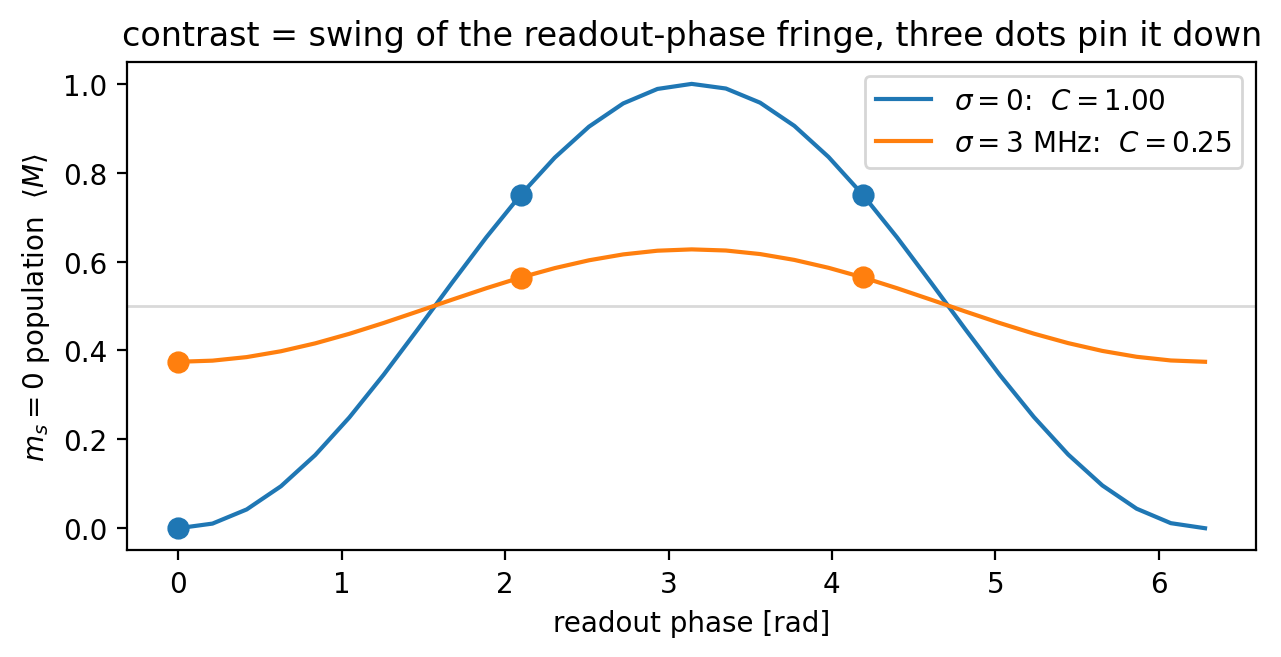

In [8]:
phase_scan = np.linspace(0, 2 * np.pi, 31)
fringe_phase_narrow = np.array([ensemble_population(append_rectangular_ramsey, 0.0, ph) for ph in phase_scan])
fringe_phase_broad = np.array([ensemble_population(append_rectangular_ramsey, 3.0, ph) for ph in phase_scan])
samples_narrow = [ensemble_population(append_rectangular_ramsey, 0.0, ph) for ph in readout_phases]
samples_broad = [ensemble_population(append_rectangular_ramsey, 3.0, ph) for ph in readout_phases]

plt.figure(figsize=(6.5, 3.4))
plt.plot(phase_scan, fringe_phase_narrow, '-', color='C0',
         label=fr'$\sigma = 0$:  $C = {contrast_first_harmonic(samples_narrow, readout_phases):.2f}$')
plt.plot(phase_scan, fringe_phase_broad, '-', color='C1',
         label=fr'$\sigma = 3$ MHz:  $C = {contrast_first_harmonic(samples_broad, readout_phases):.2f}$')
plt.plot(readout_phases, samples_narrow, 'o', color='C0', markersize=7)
plt.plot(readout_phases, samples_broad, 'o', color='C1', markersize=7)
plt.axhline(0.5, color='0.85', lw=1, zorder=0)
plt.xlabel('readout phase [rad]')
plt.ylabel(r'$m_s{=}0$ population  $\langle M\rangle$')
plt.title('contrast = swing of the readout-phase fringe, three dots pin it down')
plt.legend()
plt.tight_layout()
plt.show()

That deterministic average is an **11-point Gauss&ndash;Hermite quadrature**: the continuous Gaussian
ensemble is replaced by 11 representative detunings $\delta_k = \sigma\,x_k$, each carrying a weight
$w_k$ (with $\sum_k w_k = 1$). The nodes concentrate where the Gaussian has its mass, so 11 points
already give a machine-accurate average where random sampling would need thousands &mdash; and the
curves come out reproducible, not shot-noise-limited.

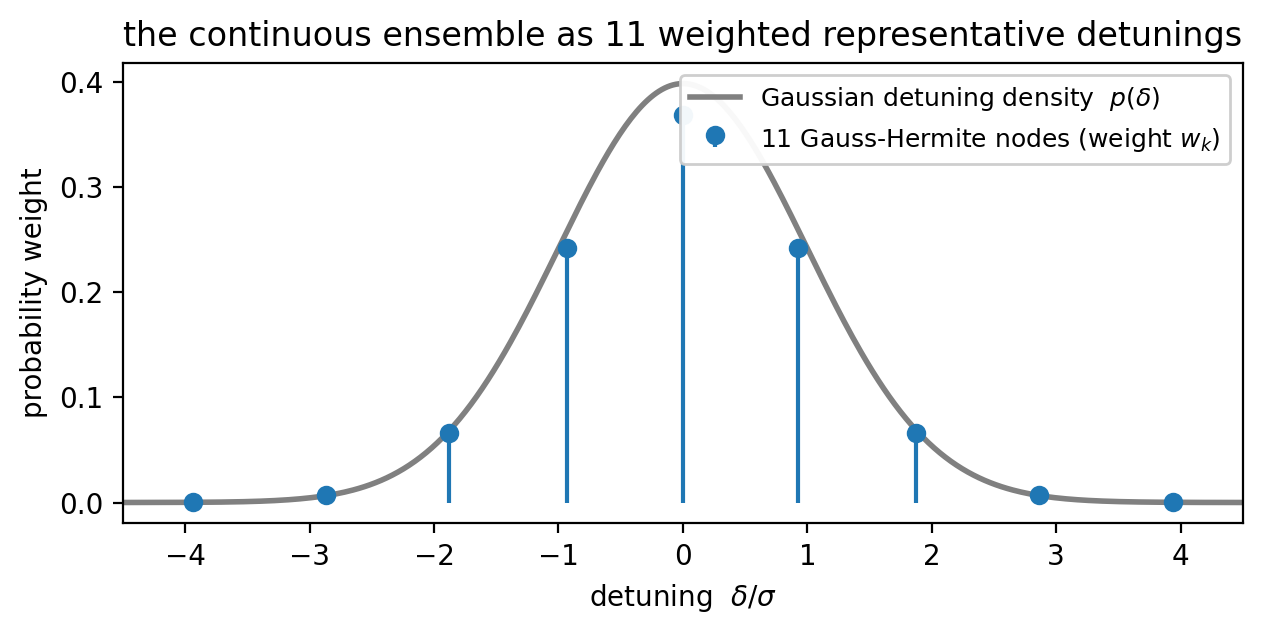

In [9]:
x = np.linspace(-4.5, 4.5, 400)
plt.figure(figsize=(6.5, 3.3))
plt.plot(x, np.exp(-x**2 / 2) / np.sqrt(2 * np.pi), color='0.5', lw=2,
         label=r'Gaussian detuning density  $p(\delta)$')
plt.stem(gauss_nodes, gauss_weights, linefmt='C0-', markerfmt='C0o', basefmt=' ',
         label=r'11 Gauss-Hermite nodes (weight $w_k$)')
plt.xlim(-4.5, 4.5)
plt.xlabel(r'detuning  $\delta / \sigma$')
plt.ylabel('probability weight')
plt.title('the continuous ensemble as 11 weighted representative detunings')
plt.legend(loc='upper right', framealpha=0.95, fontsize=9)
plt.tight_layout()
plt.show()

#### Watching the fringe wash out

The quickest way to see the broadening bite is the **Ramsey fringe itself**. Sweeping the sensed field
at readout phase 0 (as in Part 1) traces the fringe in $\langle M\rangle$, and its peak-to-peak swing
*is* the contrast $C$. Overlaying the noiseless single-spin fringe from Part 1 with a representative
ensemble ($\sigma = 3$ MHz) under the rectangular pulse shows that swing collapse directly.

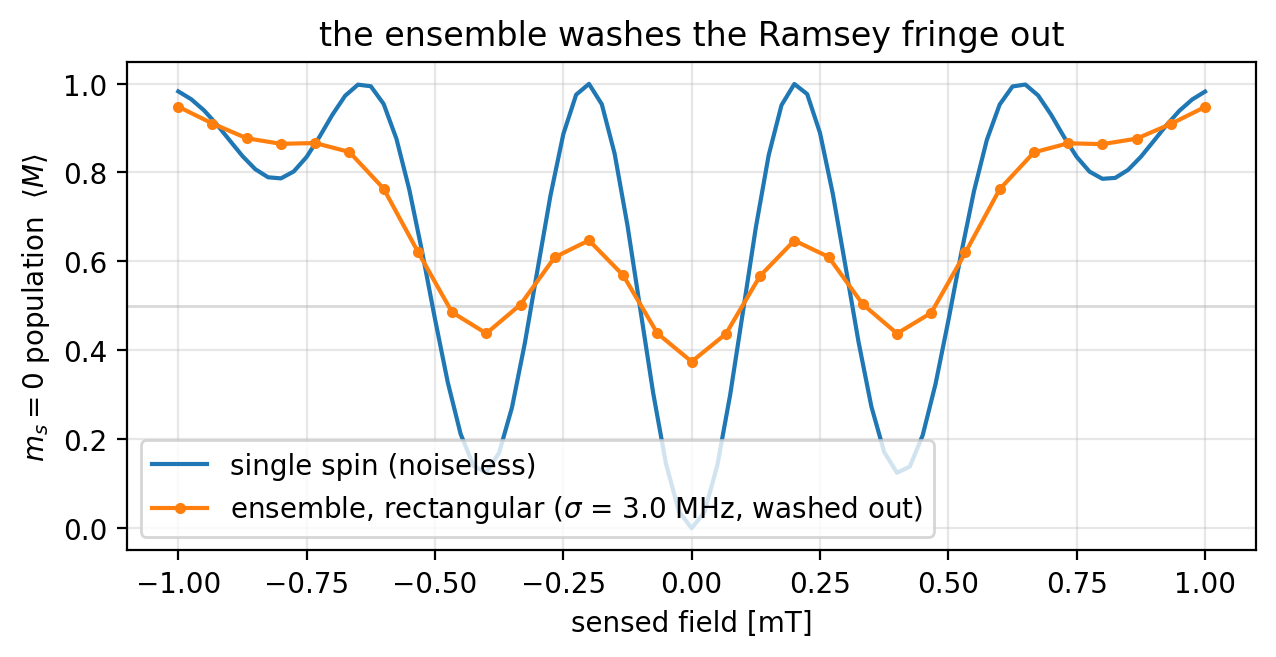

In [10]:
sigma_show = 3.0
fringe_fields = np.linspace(-1.0e-3, 1.0e-3, 31)  # +-1 mT

fringe_rectangular = np.array([ensemble_population(append_rectangular_ramsey, sigma_show, 0.0, field=field)
                               for field in fringe_fields])

plt.figure(figsize=(6.5, 3.4))
plt.plot(fields * 1e3, fringe_single, '-', color='C0',
         label='single spin (noiseless)')
plt.plot(fringe_fields * 1e3, fringe_rectangular, 'o-', markersize=3, color='C1',
         label=fr'ensemble, rectangular ($\sigma$ = {sigma_show} MHz, washed out)')
plt.axhline(0.5, color='0.85', lw=1, zorder=0)
plt.xlabel('sensed field [mT]')
plt.ylabel(r'$m_s{=}0$ population  $\langle M\rangle$')
plt.title('the ensemble washes the Ramsey fringe out')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Quantifying the collapse

That single snapshot becomes a trend by scanning the linewidth $\sigma$: at each $\sigma$ we read off
the contrast $C$ (first harmonic over the three readout phases) and the sensitivity
$\eta = 1/(\gamma_e C\sqrt{\tau})$ it implies.

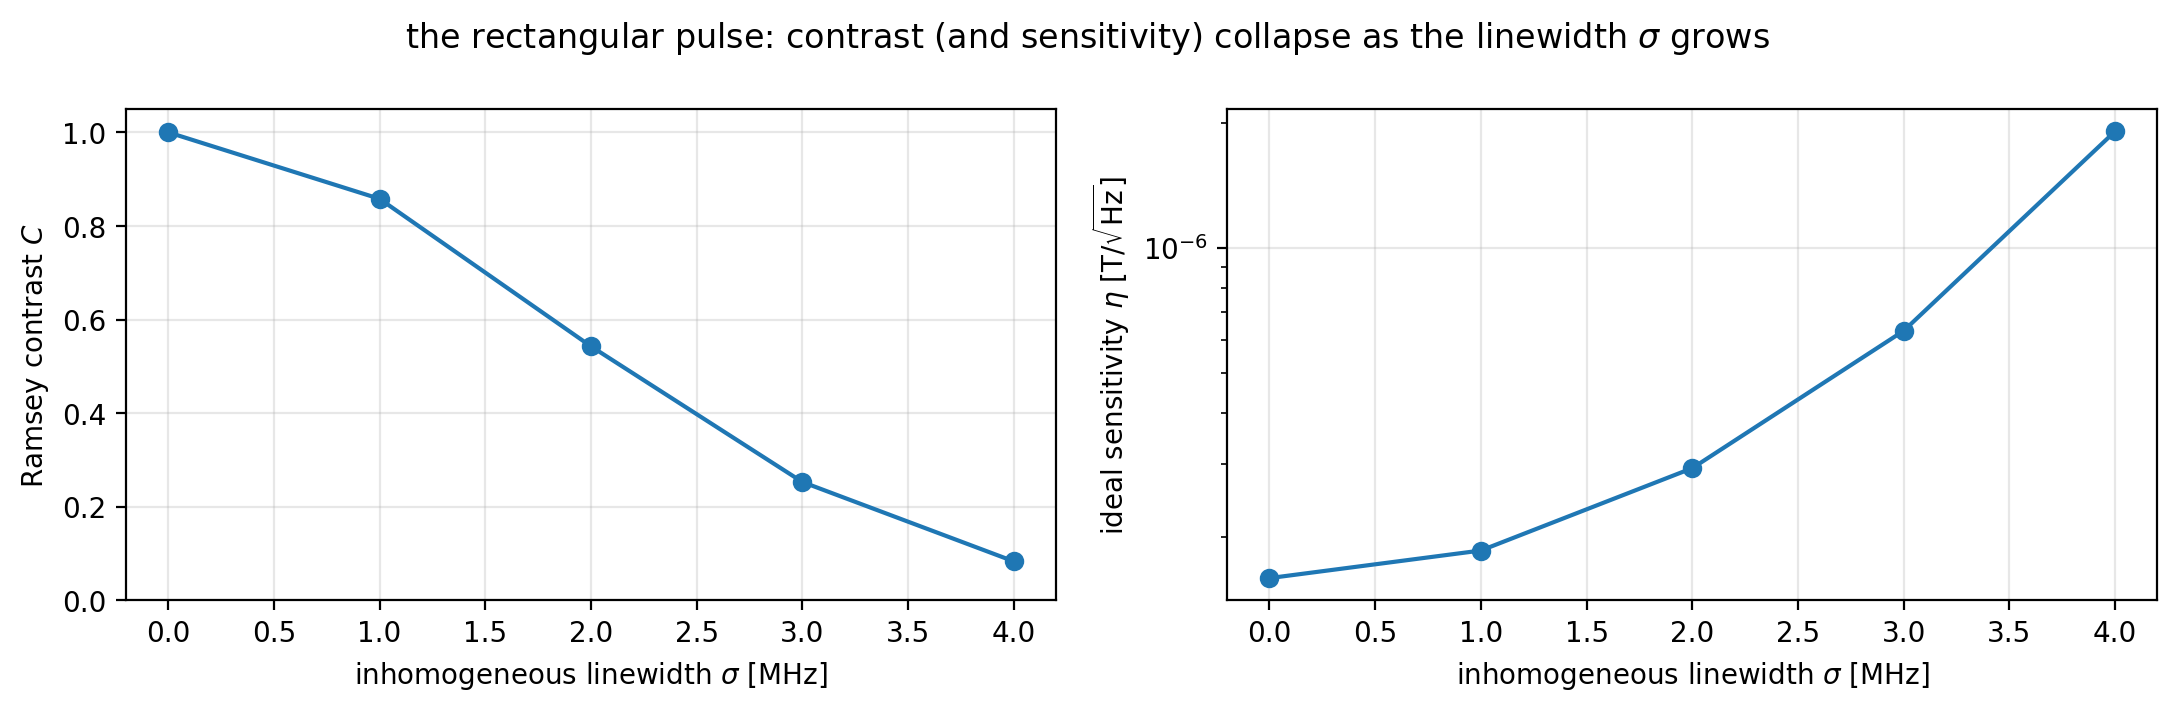

In [11]:
sigmas = np.array([0.0, 1.0, 2.0, 3.0, 4.0])  # up to ~ the Rabi frequency
contrast_rectangular = np.array([ramsey_contrast(append_rectangular_ramsey, s) for s in sigmas])
sensitivity_rectangular = np.array([sensitivity(c) for c in contrast_rectangular])

fig, axs = plt.subplots(1, 2, figsize=(11, 3.6))
axs[0].plot(sigmas, contrast_rectangular, 'o-', color='C0')
axs[0].set_xlabel(r'inhomogeneous linewidth $\sigma$ [MHz]')
axs[0].set_ylabel('Ramsey contrast $C$')
axs[0].set_ylim(0, 1.05)
axs[0].grid(alpha=0.3)
axs[1].semilogy(sigmas, sensitivity_rectangular, 'o-', color='C0')
axs[1].set_xlabel(r'inhomogeneous linewidth $\sigma$ [MHz]')
axs[1].set_ylabel(r'ideal sensitivity $\eta$ [T/$\sqrt{\mathrm{Hz}}$]')
axs[1].grid(alpha=0.3)
fig.suptitle(r'the rectangular pulse: contrast (and sensitivity) collapse as the linewidth $\sigma$ grows')
plt.tight_layout()
plt.show()

The contrast &mdash; and with it the sensitivity &mdash; falls off steadily as the linewidth $\sigma$
grows. Crucially, the detuning spread is **static** (quasistatic / inhomogeneous), so it is
**refocusable**: a pulse designed as part of the whole sequence can undo both the mis-rotation *and*
the free-evolution dephasing, rather than just preparing a better superposition. Building that pulse
is **Part 3**.

## Part 3: Optimizing the pulse for robust sensitivity

We replace the rectangular $\pi/2$ with a **piecewise-constant (GRAPE-style) pulse**
(`add_discrete_pulse`, the two microwave quadratures) and let
<span style="font-variant: small-caps;">Simphony</span>'s autodiff shape it. The objective is **the
sensing quantity itself** &mdash; the ensemble sensitivity $\eta$ &mdash; scored on the *full Ramsey
interferometer* (the same pulse used for preparation and readout), averaged over the inhomogeneous
detuning ensemble with the same deterministic Gauss&ndash;Hermite quadrature as Part 2 (so the
objective is exactly the sensitivity measured afterwards) and a small control-amplitude grid.

> **Running the optimization.** <span style="font-variant: small-caps;">Simphony</span> differentiates
> all the way through the full Ramsey interferometer, so the optimizer improves the *sensing figure of
> merit directly*. Gradient-based optimization loops are compute-intensive, so &mdash; as is standard
> in optimal control &mdash; the optimization is run **once, offline** (a few tens of minutes); the
> resulting pulse is then loaded and evaluated with the NumPy backend.

<details>
<summary>Show the offline optimization code</summary>

```python
import simphony
simphony.Config.set_platform('gpu')
simphony.Config.set_autodiff_mode(True)  # differentiable simulation
import jax.numpy as jnp
from jax import value_and_grad
from scipy.optimize import minimize

n_segments = 12
duration_opt = 0.05  # optimized pulse duration [us]
dt = duration_opt / n_segments
readout_phases = jnp.array([0.0, 2 * np.pi / 3, 4 * np.pi / 3])  # 3 readout phases -> true visibility
amplitude_grid = [0.9, 1.1]  # control-amplitude (Rabi) spread
sigma_train = 4.0  # inhomogeneous linewidth [MHz]

def ensemble_population(samples, scale, readout_phase):
    '''Deterministic Gauss-Hermite average of <M> over the detuning spread -- the same quadrature
    (gauss_nodes / gauss_weights) the Part 2 evaluation uses, so the objective is exactly the
    sensitivity we measure later, and the gradient stays smooth (no random-shot sampling).'''
    pulse = samples * scale
    population = 0.0
    for node, weight in zip(gauss_nodes, gauss_weights):
        model.remove_all_pulses()
        model.driving_field('MW_x').add_discrete_pulse(samples=pulse,
                                                       frequency=frequency,
                                                       dt=dt)
        model.driving_field('MW_x').add_wait(wait)
        model.driving_field('MW_x').add_discrete_pulse(samples=pulse * jnp.exp(1j * readout_phase),
                                                       frequency=frequency,
                                                       dt=dt)
        end = model.driving_field('MW_x').last_pulse_end
        model.driving_field('DC_z').add_rectangle_pulse(amplitude=(sigma_train * node) / gyromagnetic_ratio,
                                                        frequency=0.,
                                                        phase=0.,
                                                        duration=end,
                                                        start=0.)
        result = model.simulate_time_evolution(n_eval=2,
                                               n_split=50,
                                               apply_noise=False,
                                               verbose=False)
        result.initial_state = model.productstate({'e': 0})
        population = population + weight * result.expectation_value('M',
                                                                    t_idx=-1,
                                                                    in_qubit_subspace=False).ravel()[0]
    return population

def mean_sensitivity(params):  # the sensing figure of merit
    samples = params[:n_segments] + 1j * params[n_segments:]
    total = 0.0
    for scale in amplitude_grid:
        signals = jnp.array([ensemble_population(samples, scale, phase) for phase in readout_phases])
        cos_component = (2 / 3) * jnp.sum(signals * jnp.cos(readout_phases))
        sin_component = (2 / 3) * jnp.sum(signals * jnp.sin(readout_phases))
        contrast = jnp.clip(2 * jnp.hypot(cos_component, sin_component), 1e-3, None)  # <M> swings by C peak-to-peak
        total = total + 1.0 / (gyromagnetic_ratio * 1e6 * contrast * jnp.sqrt(wait * 1e-6))
    return total / len(amplitude_grid)

value_and_gradient = value_and_grad(mean_sensitivity)
def objective(x):
    value, gradient = value_and_gradient(jnp.array(x))
    return float(value), np.asarray(gradient, dtype=float)

seed_amplitude = model.rabi_amplitude_qubit(driving_field_name='MW_x',
                                            period_time=4 * duration_opt,
                                            spin_name='e')
np.random.seed(0)
initial = np.concatenate([np.full(n_segments, float(seed_amplitude)), np.zeros(n_segments)]) \
          + 0.05 * float(seed_amplitude) * np.random.randn(2 * n_segments)
peak = 6 * amplitude  # amplitude bound (power budget)

result = minimize(objective, initial, jac=True, method='L-BFGS-B',
                  bounds=[(-peak, peak)] * (2 * n_segments), options={'maxiter': 60})
optimized_params = result.x
```

</details>

The converged parameters from that offline run are stored below:

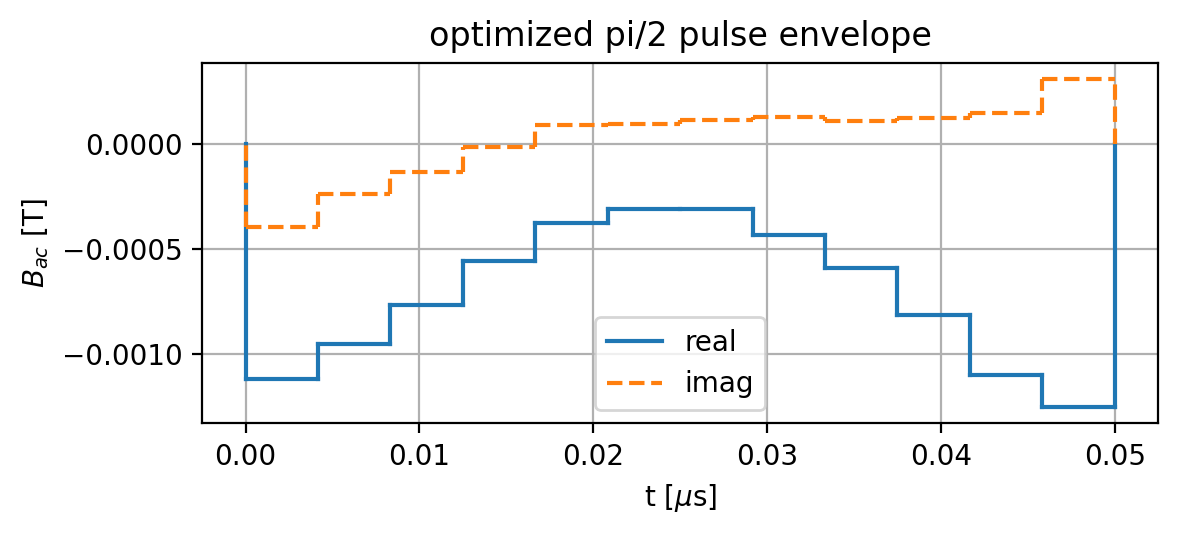

In [12]:
optimized_params = np.array([-0.001122743, -0.000954964, -0.000769573, -0.000559056, -0.000375531, -0.000312623, -0.00031127, -0.00043495, -0.000593487, -0.000817884, -0.001103305, -0.001253909, -0.000396127, -0.00023851, -0.000136765, -1.4079e-05, 9.1171e-05, 9.2421e-05, 0.000114065, 0.000128478, 0.000107912, 0.000121936, 0.000147232, 0.000307588])
n_segments = 12
duration_opt = 0.05  # optimized pulse duration [us]
dt = duration_opt / n_segments
optimized_samples = optimized_params[:n_segments] + 1j * optimized_params[n_segments:]

def append_optimized_ramsey(scale, readout_phase):
    pulse = optimized_samples * scale
    model.driving_field('MW_x').add_discrete_pulse(samples=pulse,
                                                   frequency=frequency,
                                                   dt=dt)
    model.driving_field('MW_x').add_wait(wait)
    model.driving_field('MW_x').add_discrete_pulse(samples=pulse * np.exp(1j * readout_phase),
                                                   frequency=frequency,
                                                   dt=dt)

model.remove_all_pulses()
model.driving_field('MW_x').add_discrete_pulse(samples=optimized_samples,
                                               frequency=frequency,
                                               dt=dt)
fig, ax = plt.subplots(figsize=(6, 2.8))
model.driving_field('MW_x').plot_pulses(function='complex_envelope', ax=ax)
ax.set_title('optimized pi/2 pulse envelope')
plt.tight_layout()
plt.show()

### Result: sensitivity that survives the ensemble

The clearest view is the **Ramsey fringe itself**. On the same sensed-field sweep and the same
ensemble ($\sigma = 3$ MHz) as Part 2, we add the **optimized-pulse** fringe to the noiseless single
spin and the washed-out rectangular ensemble. It stays **crisp** &mdash; that recovered visibility is
exactly the recovered sensitivity.

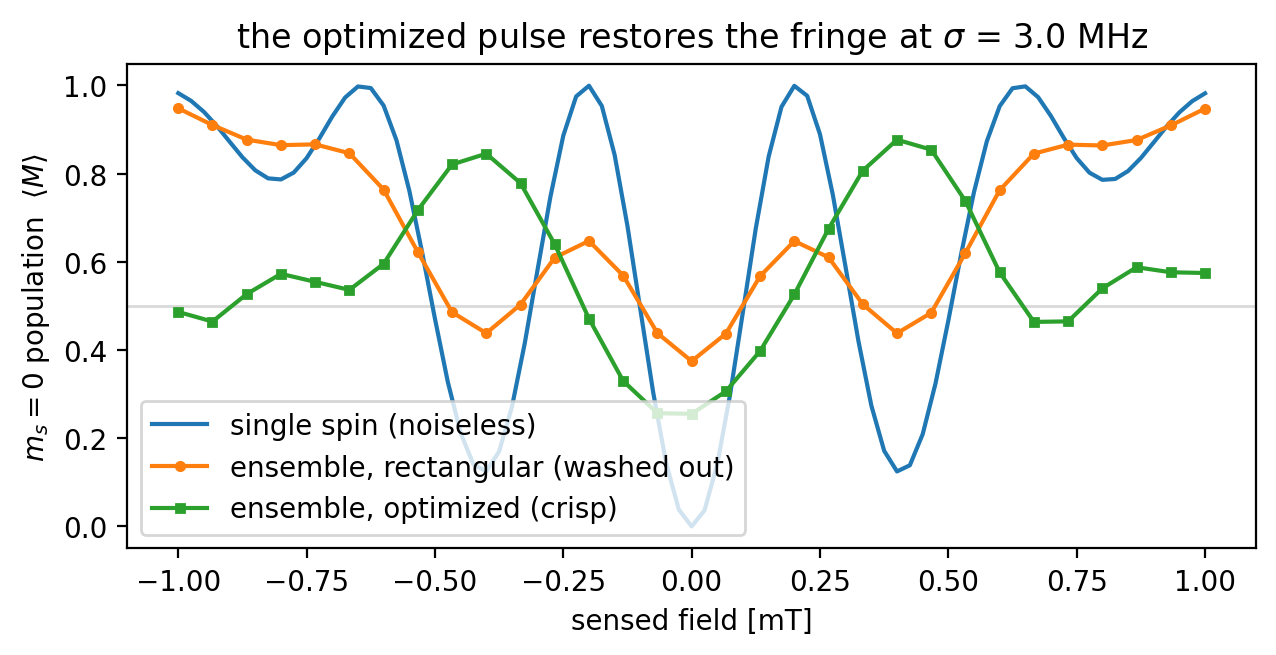

In [13]:
fringe_optimized = np.array([ensemble_population(append_optimized_ramsey, sigma_show, 0.0, field=field)
                             for field in fringe_fields])

plt.figure(figsize=(6.5, 3.4))
plt.plot(fields * 1e3, fringe_single, '-', color='C0', label='single spin (noiseless)')
plt.plot(fringe_fields * 1e3, fringe_rectangular, 'o-', markersize=3, color='C1', label='ensemble, rectangular (washed out)')
plt.plot(fringe_fields * 1e3, fringe_optimized, 's-', markersize=3, color='C2', label='ensemble, optimized (crisp)')
plt.axhline(0.5, color='0.85', lw=1, zorder=0)
plt.xlabel('sensed field [mT]')
plt.ylabel(r'$m_s{=}0$ population  $\langle M\rangle$')
plt.title(fr'the optimized pulse restores the fringe at $\sigma$ = {sigma_show} MHz')
plt.legend()
plt.tight_layout()
plt.show()

#### The gain across the linewidth

Sweeping the inhomogeneous linewidth $\sigma$ turns that single snapshot into a trend, comparing the
two pulses on equal footing &mdash; the full two-pulse Ramsey interferometer, same ensemble.

This is the same comparison Jauch *et al.* make experimentally. When the microwave drive is
**homogeneous** &mdash; every spin seeing the same Rabi frequency &mdash; optimal control barely beats
a rectangular $\pi/2$ ($\sim\!1.6\times$): a hard pulse is already close to optimal. Under a realistic
**inhomogeneous** drive, where the Rabi strength varies across the ensemble, the rectangular pulse
mis-rotates the off-resonant spins much more, so the *relative* benefit of optimal control grows
($\sim\!3\times$ in their setup) &mdash; the more inhomogeneous the drive, the more it helps. Our
$\sigma$-scan is the same story along a different axis: they vary the microwave-field homogeneity,
we vary the detuning linewidth $\sigma$. The enhancement below is close to $1$ at $\sigma = 0$ and
grows with $\sigma$; the absolute numbers differ, but the trend &mdash; optimal control helping
**more** as the inhomogeneity it fights grows &mdash; carries over.

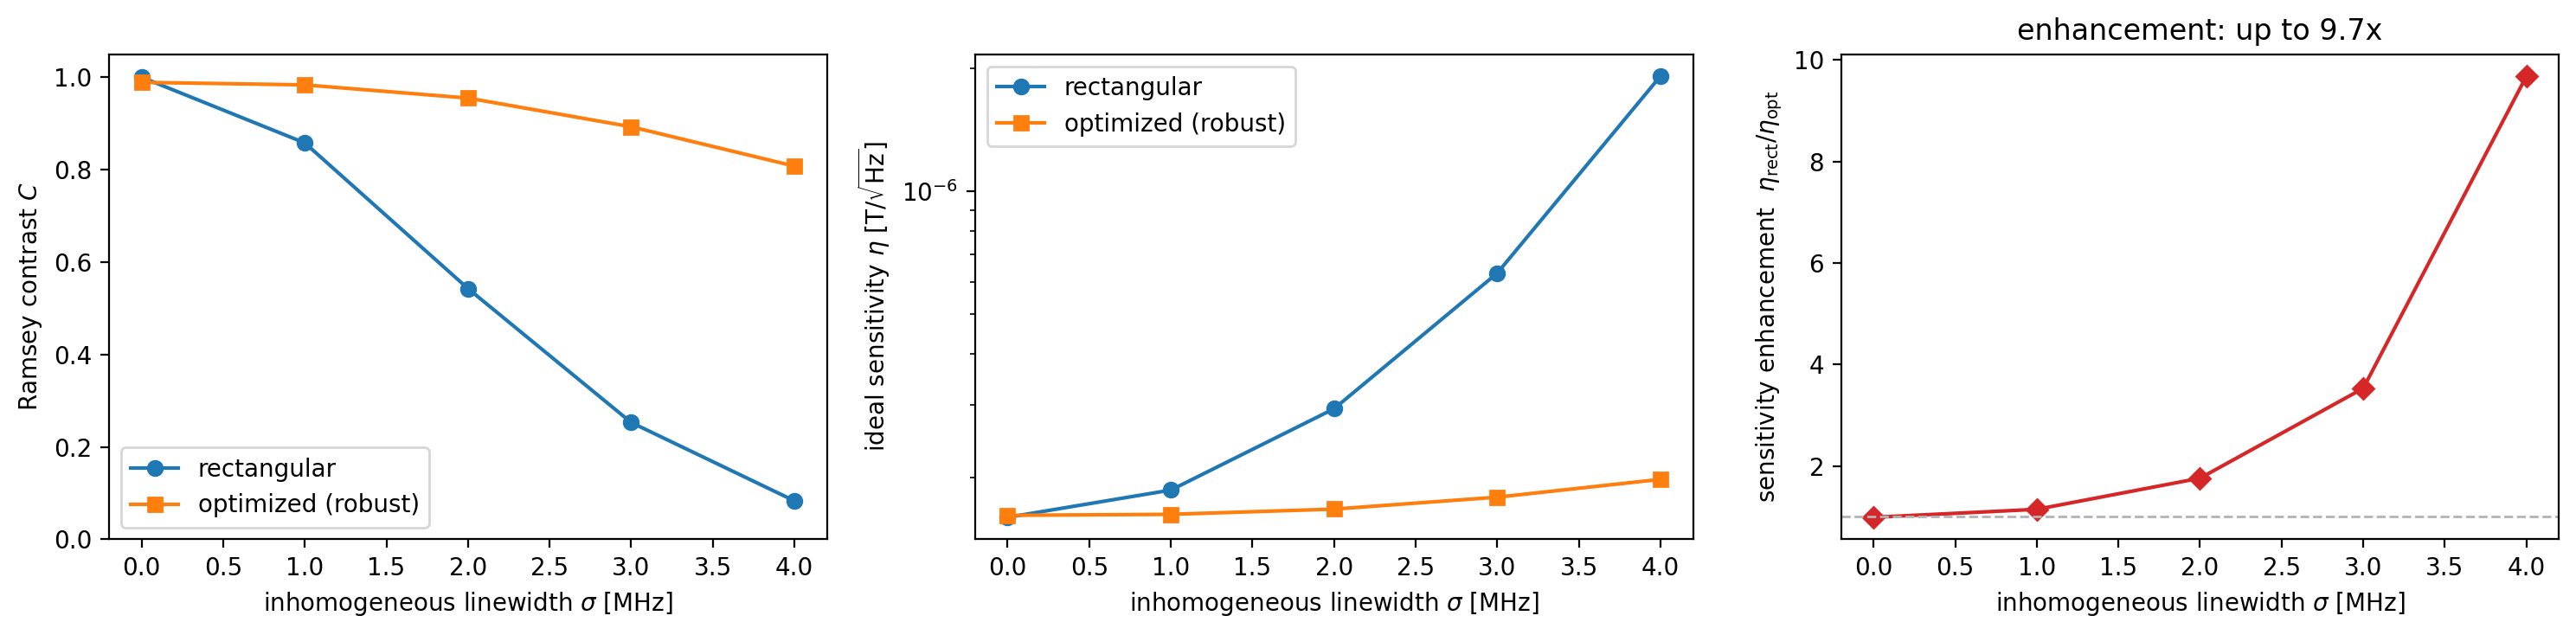

In [14]:
contrast_optimized = np.array([ramsey_contrast(append_optimized_ramsey, s) for s in sigmas])
sensitivity_optimized = np.array([sensitivity(c) for c in contrast_optimized])
enhancement = sensitivity_rectangular / sensitivity_optimized

fig, axs = plt.subplots(1, 3, figsize=(15, 3.8))
axs[0].plot(sigmas, contrast_rectangular, 'o-', label='rectangular')
axs[0].plot(sigmas, contrast_optimized, 's-', label='optimized (robust)')
axs[0].set_xlabel(r'inhomogeneous linewidth $\sigma$ [MHz]')
axs[0].set_ylabel('Ramsey contrast $C$')
axs[0].set_ylim(0, 1.05)
axs[0].legend()

axs[1].semilogy(sigmas, sensitivity_rectangular, 'o-', label='rectangular')
axs[1].semilogy(sigmas, sensitivity_optimized, 's-', label='optimized (robust)')
axs[1].set_xlabel(r'inhomogeneous linewidth $\sigma$ [MHz]')
axs[1].set_ylabel(r'ideal sensitivity $\eta$ [T/$\sqrt{\mathrm{Hz}}$]')
axs[1].legend()

axs[2].plot(sigmas, enhancement, 'D-', color='C3')
axs[2].axhline(1.0, color='0.7', lw=1, ls='--')
axs[2].set_xlabel(r'inhomogeneous linewidth $\sigma$ [MHz]')
axs[2].set_ylabel(r'sensitivity enhancement  $\eta_\mathrm{rect}/\eta_\mathrm{opt}$')
axs[2].set_title(f'enhancement: up to {np.max(enhancement):.1f}x')

plt.tight_layout()
plt.show()

## Summary and caveats

- **Part 1** established DC magnetometry with a single NV spin: a Ramsey sequence turns a field into a
  phase and then a population, **slope detection** reads it out linearly at the maximum-slope working
  point, and the **sensitivity** is $\eta_B = 1/(\gamma_e C\sqrt{\tau})$ &mdash; set by the transducer
  gain $\gamma_e$, the sensing time $\tau$, and the fringe contrast $C$.
- **Part 2** showed what an **ensemble** does to that measurement: inhomogeneous broadening (a static
  detuning spread $\sigma$, the same $T_2^*\approx1/(2\pi\sigma)$ limit as Part 1) both mis-rotates
  off-resonant spins under a rectangular $\pi/2$ and dephases the fringe during free evolution, so the
  contrast $C$ &mdash; and, via $\eta \propto 1/C$, the sensitivity &mdash; collapses as $\sigma$ grows.
- **Part 3** optimized the sensing figure of merit itself &mdash; not an abstract gate fidelity
  &mdash; by differentiating the full Ramsey interferometer through
  <span style="font-variant: small-caps;">Simphony</span>. Because the broadening is **static**
  (quasistatic / inhomogeneous), it is refocusable: a single pulse pair optimized over the whole
  sequence recovers the contrast lost to *both* mis-rotation and free-evolution dephasing, improving
  the ensemble sensitivity several-fold at large $\sigma$ &mdash; the same qualitative trend Jauch
  *et al.* measure experimentally, where optimal control gains **more** as the microwave field becomes
  **less** homogeneous.
- **Caveats.** The optimization targets both the *detuning* spread and (via a $\pm10\%$
  `amplitude_grid`) the **control-amplitude (Rabi) inhomogeneity** &mdash; the drive strength varies
  across a real wide-field ensemble. Widening those training windows trades one robustness for the
  other. Piecewise-constant pulses are used in this strong-drive, short-$\tau$ regime; smooth,
  bandwidth-limited pulses (via finer segments or `rise_time`/`fall_time`) are a direct extension. What this cannot fix is **dynamic** decoherence ($T_2$, from *fluctuating* rather
  than static fields): no fixed pulse pair refocuses it, and it ultimately caps $\tau$ &mdash; that
  regime needs dynamical decoupling and the noise machinery of
  `6_example_ramsey_with_quasistatic_noise.ipynb`.